In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from algbench import read_as_pandas
from tspn_bnb2.misc.paper_style import HALFWIDEFIGURE, init_params
from tspn_bnb2.schemas import AnnotatedInstance, AnnotatedSolution

init_params()

In [2]:
search_strategy_labels = {
    "CheapestChildDepthFirst": "DFS",
    "CheapestBreadthFirst": "BFS",
    "DfsBfs": "DFS+BFS",
    "Random": "Random",
}

In [3]:
def read_row(row):
    instance = AnnotatedInstance.model_validate_json(
        row["parameters"]["args"]["kwargs"]["instance_json"]
    )
    solution = (
        AnnotatedSolution.model_validate_json(row["result"]["solution"])
        if row["result"]["solution"]
        else None
    )

    if solution is None:
        print(
            row["result"]["error"],
            row["parameters"]["args"]["kwargs"]["instance_name"],
            row["parameters"]["args"]["alg_params"],
        )
        return None

    return {
        "solution": solution,
        "upper_bound": solution.upper_bound,
        "lower_bound": solution.lower_bound,
        "relative_gap": solution.relative_gap,
        "is_optimal": solution.is_optimal,
        "instance_name": row["parameters"]["args"]["kwargs"]["instance_name"],
        "instance": instance,
        "solve_time": row["result"].get("solve_time"),
        "n": instance.num_polygons(),
        "search_strategy": search_strategy_labels[
            row["parameters"]["args"]["alg_params"]["search"]
        ],
        "eps": row["parameters"]["args"]["alg_params"]["eps"],
    }


benchmark = read_as_pandas("results_search_strategy", read_row)
print(benchmark.columns)
benchmark = benchmark.sort_values(by=["search_strategy"], ascending=False)

print("loaded", len(benchmark), "runs")

Index(['solution', 'upper_bound', 'lower_bound', 'relative_gap', 'is_optimal',
       'instance_name', 'instance', 'solve_time', 'n', 'search_strategy',
       'eps'],
      dtype='str')
loaded 408 runs


In [4]:
benchmark.groupby(by=["search_strategy"])["is_optimal"].value_counts()

search_strategy  is_optimal
BFS              False          88
                 True           48
DFS              True           99
                 False          37
DFS+BFS          True          102
                 False          34
Name: count, dtype: int64

In [5]:
# validate that solutions are correct.
for eps in benchmark["eps"].unique():
    n_checks = 0
    current_bench = benchmark[benchmark["eps"] == eps]
    for _, row in current_bench.iterrows():
        solution = row["solution"]
        if solution is None or solution.trajectory.is_empty:
            continue
        assert solution.check_feasibility(row["instance"], eps=1), row["search_strategy"]
        same_instance = current_bench[current_bench["instance_name"] == row["instance_name"]]
        for _, other in same_instance.iterrows():
            if other["solution"] is None:
                continue

            check = solution.plausibility_check(
                other["solution"],
                eps=eps,
            )
            assert check["valid"], f"Check failed for {row['instance_name']} {check}"
            n_checks += 1

    print(n_checks, "checks succeeded")

480 checks succeeded
480 checks succeeded


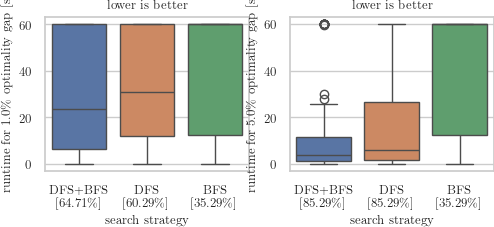

In [7]:
fig, axs = plt.subplots(ncols=2)

for ax, eps in zip(axs, sorted(benchmark["eps"].unique())):
    current_bench = benchmark[benchmark["eps"] == eps]
    sns.boxplot(current_bench, x="search_strategy", y="solve_time", hue="search_strategy", ax=ax)

    xticks = ax.get_xticks()
    xticklabels = []

    for label in ax.get_xticklabels():
        solutions_for_label = current_bench[(current_bench["search_strategy"] == label.get_text())]
        optimal_percentage = len(solutions_for_label[solutions_for_label["is_optimal"]]) / len(
            solutions_for_label
        )

        label = label.get_text() + f"\n[{round(optimal_percentage * 100, 2)}\\%]"
        xticklabels.append(label)

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)
    ax.set_title("lower is better")
    ax.set_xlabel("search strategy")
    ax.set_ylabel(rf"runtime for ${eps * 100}\%$ optimality gap [s]")

fig.savefig("../plots/rq2_search_strategy/runtimes.pdf", bbox_inches="tight")

/var/folders/tp/x38cpg5x7zd2p54xjvncbjtm0000gn/T/ipykernel_1108/3704488886.py:3: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.boxplot(


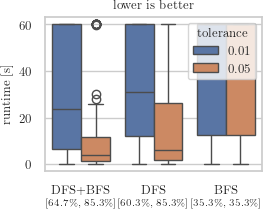

In [9]:
fig, ax = plt.subplots(ncols=1, figsize=HALFWIDEFIGURE)

sns.boxplot(
    benchmark, x="search_strategy", y="solve_time", hue="eps", ax=ax, palette=sns.color_palette()
)

xticks = ax.get_xticks()
xticklabels = []

for label in ax.get_xticklabels():
    optimal_percentage_for_eps = {}
    for eps in sorted(benchmark["eps"].unique()):
        current_bench = benchmark[benchmark["eps"] == eps]
        solutions_for_label = current_bench[(current_bench["search_strategy"] == label.get_text())]
        optimal_percentage_for_eps[eps] = len(
            solutions_for_label[solutions_for_label["is_optimal"]]
        ) / len(solutions_for_label)

    percentages = ", ".join(
        f"{round(optimal_percentage_for_eps[eps] * 100, 1)}\\%"
        for eps in sorted(benchmark["eps"].unique())
    )
    label = label.get_text() + f"\n\\scriptsize{{[{percentages}]}}"
    xticklabels.append(label)

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_title("lower is better")
ax.set_xlabel("")
ax.set_ylabel("runtime [s]")

ax.legend(loc="upper right").set_title("tolerance")

fig.savefig("../plots/rq2_search_strategy/runtimes_combined.pdf", bbox_inches="tight")

In [10]:
# adapted from OR-Tools Primer: https://d-krupke.github.io/cpsat-primer/08_benchmarking.html#performance-plots-for-solution-quality-within-a-time-limit

import numpy as np
import pandas as pd
from matplotlib.axes import Axes


def plot_performance_profile(
    data: pd.DataFrame,
    ax: Axes,
    instance_column: str,
    strategy_column: str,
    metric_column: str,
    direction: str,
    comparison: str = "relative",
    title: str | None = None,
    highlight_best: bool = False,
    scale: str | None = None,
    log_base: int = 2,
    eps: float = 0.01,
) -> Axes:
    """Plot a performance profile.

    Either on a relative-ratio or absolute-difference basis:
      - For comparison="relative":
          x-axis: performance ratio t (log scale if t_max > 10)
          t = (value / best) if direction="min",
          or t = (best / value) if direction="max".
      - For comparison="absolute":
          x-axis: absolute difference D = (value - best)
          if direction="min",
          or D = (best - value) if direction="max".
      - y-axis: proportion of problems with t (or D) <= x
        for each solver.
      - If highlight_best=True, detect and bold the dominating
        solver curve (AUC in appropriate space).
      - Ensures a reasonable number of ticks on the x-axis.

    Args:
        data: DataFrame with columns [instance, strategy, metric].
        instance_column: column identifying each problem instance.
        strategy_column: column identifying each solver/strategy.
        metric_column: column of the performance metric.
        direction: "min" if lower metric is better,
            "max" if higher is better.
        comparison: "relative" or "absolute".
        title: Optional plot title.
        highlight_best: If True, find the solver with largest
            AUC and draw it in bold.
        ax: An existing matplotlib Axes to draw into.
        scale: x-axis scale override ("linear" or "log");
            if None, chosen automatically.
        log_base: base for log scale if used (default 2).
        eps: tolerance for comparison.

    Returns:
        The matplotlib Axes containing the performance profile.

    """
    if direction not in ("min", "max"):
        raise ValueError("`direction` must be 'min' or 'max'.")
    if comparison not in ("relative", "absolute"):
        raise ValueError("`comparison` must be 'relative' or 'absolute'.")

    # 1) Compute best value per instance
    best_val = data.groupby(instance_column)[metric_column].agg(direction)

    # 2) Pivot to get per-instance x per-strategy medians
    pivot = (
        data.groupby([instance_column, strategy_column])[metric_column]
        .median()
        .unstack(fill_value=np.nan)
    )

    # 3) Build comparison matrix C[p, s]
    comp = pd.DataFrame(index=pivot.index, columns=pivot.columns, dtype=float)

    if comparison == "relative":
        best_val = best_val * (1 - eps) if direction == "min" else best_val * (1 + eps)

        for strat in pivot.columns:
            if direction == "min":
                comp[strat] = pivot[strat] / best_val
            else:  # direction == "max"
                comp[strat] = best_val / pivot[strat]

        comp = comp.replace([np.inf, -np.inf, 0.0], np.nan)

    else:  # comparison == "absolute"
        for strat in pivot.columns:
            if direction == "min":
                comp[strat] = pivot[strat] - best_val
            else:  # direction == "max"
                comp[strat] = best_val - pivot[strat]
        comp = comp.replace([np.inf, -np.inf], np.nan)

    # 4) Collect all distinct x-values, including baseline
    all_vals = comp.to_numpy().flatten()
    finite_vals = all_vals[np.isfinite(all_vals)]
    baseline = 1.0 if comparison == "relative" else 0.0
    all_x = np.unique(np.sort(finite_vals))
    all_x = np.concatenate(([baseline], all_x))
    all_x = np.unique(np.sort(all_x))

    # 5) Build performance-profile DataFrame
    n_instances = comp.shape[0]
    profile = pd.DataFrame(index=all_x, columns=comp.columns, dtype=float)

    for x in all_x:
        leq = (comp <= x).sum(axis=0)
        profile.loc[x] = leq / n_instances

    # 6) Identify dominating solver if requested (max AUC)
    best_solver = None
    if highlight_best:
        if comparison == "relative":
            log_x = np.log(all_x)
            areas = {}
            for strat in profile.columns:
                y = profile[strat].astype(float).to_numpy()
                areas[strat] = np.trapezoid(y, x=log_x)
            best_solver = max(areas, key=areas.get)
        else:
            areas = {}
            for strat in profile.columns:
                y = profile[strat].astype(float).to_numpy()
                areas[strat] = np.trapezoid(y, x=all_x)
            best_solver = max(areas, key=areas.get)

    # 8) Determine scale if not overridden
    if scale is None:
        use_log = comparison == "relative" and all_x[-1] > 10
    else:
        use_log = scale == "log"

    # 9) Plot each solver's curve
    for strat in profile.columns:
        y = profile[strat].astype(float)
        if highlight_best and strat == best_solver:
            ax.step(
                all_x,
                y,
                where="post",
                label=strat,
                linewidth=3.0,
                alpha=1.0,
            )
        else:
            ax.step(
                all_x,
                y,
                where="post",
                label=strat,
                linewidth=1.5,
                alpha=0.6 if highlight_best else 1.0,
            )

    # 10) Axis scaling and limits
    if comparison == "relative":
        if use_log:
            ax.set_xscale("log", base=log_base)
        else:
            ax.set_xscale("linear")
            ax.set_xlim(1 + eps, ax.get_xlim()[1])
        xlabel = (
            f"Within this factor of the best (log{log_base} scale)"
            if use_log
            else "Within this factor of the best (linear scale)"
        )
    else:  # absolute
        ax.set_xscale("linear")
        ax.set_xlim(0.0, all_x[-1] * 1.1)
        xlabel = "Absolute difference from the best"

    if title is not None:
        ax.set_title(title)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"\#problems [\%]")

    ax.axvline(
        x=baseline,
        color="gray",
        linestyle="--",
        alpha=0.7,
    )
    ax.grid(True, which="both", linestyle=":", linewidth=0.5)

    # 11) Legend inside lower right
    ax.legend(loc="lower right", frameon=False)

    return ax

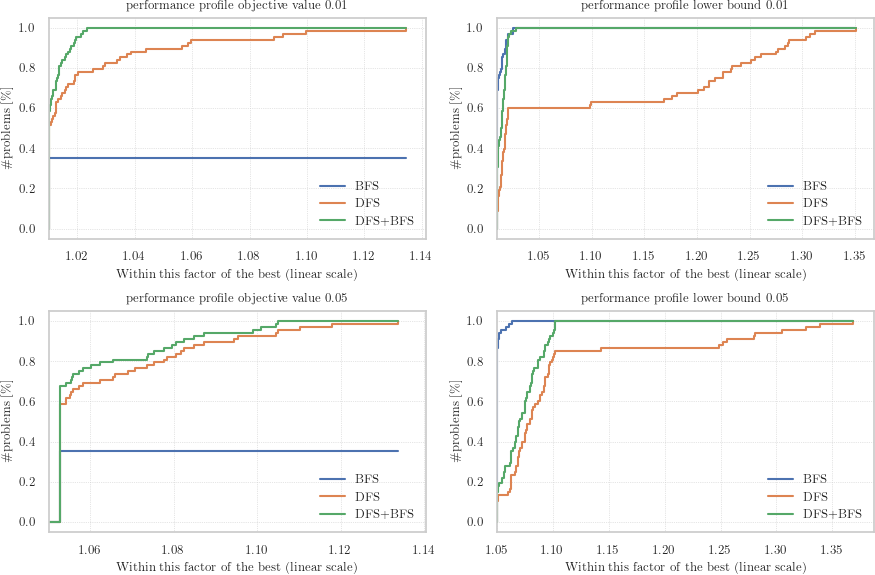

In [11]:
fig, axs = plt.subplots(ncols=2, nrows=len(benchmark["eps"].unique()), figsize=(9, 6))


for i, eps in enumerate(sorted(benchmark["eps"].unique())):
    plot_performance_profile(
        benchmark[benchmark["eps"] == eps],
        ax=axs[i, 0],
        instance_column="instance_name",
        comparison="relative",
        direction="min",
        metric_column="upper_bound",
        strategy_column="search_strategy",
        title=f"performance profile objective value {eps}",
        eps=eps,
    )

    plot_performance_profile(
        benchmark[benchmark["eps"] == eps],
        ax=axs[i, 1],
        instance_column="instance_name",
        comparison="relative",
        direction="max",
        metric_column="lower_bound",
        strategy_column="search_strategy",
        title=f"performance profile lower bound {eps}",
        eps=eps,
    )


# ax.set_title("lower is better")
# ax.set_xlabel("root node strategy")
# ax.set_ylabel("runtime (s)")
fig.tight_layout()

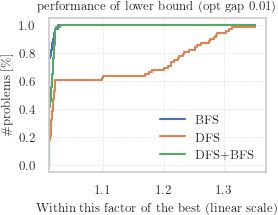

In [12]:
fig, ax = plt.subplots(figsize=HALFWIDEFIGURE)

eps = 0.01
plot_performance_profile(
    benchmark[benchmark["eps"] == eps],
    ax=ax,
    instance_column="instance_name",
    comparison="relative",
    direction="max",
    metric_column="lower_bound",
    strategy_column="search_strategy",
    title=f"performance of lower bound (opt gap {eps})",
    eps=eps,
)

fig.savefig("../plots/rq2_search_strategy/performance_lb.pdf", bbox_inches="tight")